# 03 - Interprétabilité du modèle final

Objectifs :

- charger le modèle final ;
- expliquer les variables les plus importantes globalement ;
- expliquer une décision au niveau d'un client ;
- utiliser SHAP pour améliorer la transparence du scoring crédit.

Ce notebook complète la démarche MLOps, car un modèle bancaire doit être compréhensible par les équipes métier.


In [10]:
from pathlib import Path
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, confusion_matrix

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == 'notebooks' else CURRENT_DIR
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'

print('Racine projet :', PROJECT_ROOT)

Racine projet : C:\Users\ajarl\Documents\projet_6_Initiez_vous_au_MLOPS\pret_a_depenser_scoring


## 1. Chargement du dataset et du modèle final

Le notebook utilise le modèle sauvegardé par `02_modelisation_mlflow.ipynb` dans `models/best_lightgbm.joblib`.


In [11]:
train_path = PROCESSED_DIR / 'home_credit_train_processed.csv'
model_path = MODELS_DIR / 'best_lightgbm.joblib'
threshold_path = MODELS_DIR / 'best_threshold.json'

if not train_path.exists():
    raise FileNotFoundError("Dataset préparé introuvable. Exécute d'abord le notebook 01.")
if not model_path.exists():
    raise FileNotFoundError("Modèle final introuvable. Exécute d'abord le notebook 02.")

df = pd.read_csv(train_path)
model = joblib.load(model_path)

with open(threshold_path, 'r', encoding='utf-8') as f:
    best_threshold = json.load(f)['best_threshold']

print('Modèle chargé :', model_path)
print('Seuil métier chargé :', best_threshold)
print('Shape dataset :', df.shape)

Modèle chargé : C:\Users\ajarl\Documents\projet_6_Initiez_vous_au_MLOPS\pret_a_depenser_scoring\models\best_lightgbm.joblib
Seuil métier chargé : 0.48000000000000004
Shape dataset : (307511, 1610)


In [12]:
TARGET = 'TARGET'
ID_COLS = [c for c in ['SK_ID_CURR'] if c in df.columns]

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

if ID_COLS:
    X_ids = X[ID_COLS].copy()
    X = X.drop(columns=ID_COLS)

X = X.replace([np.inf, -np.inf], np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_test :', X_test.shape)

X_test : (61503, 1608)


## 2. Résultats de prédiction du modèle final

On calcule la probabilité de défaut et la décision finale selon le seuil métier optimisé.


In [13]:
expected_features = model.named_steps["imputer"].feature_names_in_

print("Nombre de colonnes attendues :", len(expected_features))
print(expected_features[:10])

Nombre de colonnes attendues : 300
['EXT_SOURCE_3' 'EXT_SOURCE_2' 'EXT_SOURCE_1'
 'CC_CNT_DRAWINGS_ATM_CURRENT_MEAN' 'CC_CNT_DRAWINGS_CURRENT_MAX'
 'PREV_DAYS_FIRST_DRAWING_MEAN' 'PREV_DAYS_FIRST_DRAWING_MAX'
 'PREV_DAYS_FIRST_DRAWING_MIN' 'BURO_DAYS_CREDIT_MEAN'
 'BURO_BB_MONTHS_BALANCE_MIN_MEAN']


In [14]:
import numpy as np
import re

def clean_lgbm_columns(df):
    df = df.copy()
    df.columns = [
        re.sub(r"[^A-Za-z0-9_]+", "_", str(col))
        for col in df.columns
    ]
    return df

X_test_clean = clean_lgbm_columns(X_test)

# Ajouter les colonnes manquantes
for col in expected_features:
    if col not in X_test_clean.columns:
        X_test_clean[col] = np.nan

# Garder uniquement les colonnes attendues, dans le bon ordre
X_test_model = X_test_clean[expected_features].astype("float32")

print("X_test_model :", X_test_model.shape)

X_test_model : (61503, 300)


In [15]:
from sklearn.metrics import roc_auc_score, confusion_matrix

y_proba = model.predict_proba(X_test_model)[:, 1]
y_pred = (y_proba >= best_threshold).astype(int)

print("AUC sur test :", roc_auc_score(y_test, y_proba))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

clients_results = pd.DataFrame({
    "probabilite_defaut": y_proba,
    "prediction": y_pred,
    "vraie_valeur": y_test.values
})

clients_results.head()

AUC sur test : 0.7729551766678896
Matrice de confusion :
[[39378 17160]
 [ 1413  3552]]


,probabilite_defaut,prediction,vraie_valeur
0,0.486451,1,0
1,0.268700,0,0
2,0.635825,1,0
3,0.267765,0,0
4,0.695749,1,0


In [16]:
from sklearn.metrics import roc_auc_score, confusion_matrix

y_proba = model.predict_proba(X_test_model)[:, 1]
y_pred = (y_proba >= best_threshold).astype(int)

print("AUC sur test :", roc_auc_score(y_test, y_proba))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

clients_results = pd.DataFrame({
    "probabilite_defaut": y_proba,
    "prediction": y_pred,
    "vraie_valeur": y_test.values
})

clients_results.head()

AUC sur test : 0.7729551766678896
Matrice de confusion :
[[39378 17160]
 [ 1413  3552]]


,probabilite_defaut,prediction,vraie_valeur
0,0.486451,1,0
1,0.268700,0,0
2,0.635825,1,0
3,0.267765,0,0
4,0.695749,1,0


## 3. Préparation des données pour l'interprétabilité

Le modèle final est un `Pipeline` : il contient un imputer puis un modèle LightGBM. Pour SHAP, on explique le modèle LightGBM après imputation.


In [18]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

if isinstance(model, Pipeline):
    imputer = model.named_steps["imputer"]
    estimator = model.named_steps["model"]

    # Colonnes exactes attendues par l'imputer
    expected_features = imputer.feature_names_in_

    # On ajoute les colonnes manquantes si besoin
    for col in expected_features:
        if col not in X_test.columns:
            X_test[col] = np.nan

    # On garde uniquement les colonnes attendues, dans le bon ordre
    X_test_model = X_test[expected_features].astype("float32")

    # Imputation
    X_test_imputed = pd.DataFrame(
        imputer.transform(X_test_model),
        columns=expected_features,
        index=X_test_model.index
    )

else:
    estimator = model
    X_test_imputed = X_test.copy()

print("Estimateur utilisé pour SHAP :", type(estimator))
print("Données explicatives :", X_test_imputed.shape)

Estimateur utilisé pour SHAP : <class 'lightgbm.sklearn.LGBMClassifier'>
Données explicatives : (61503, 300)


In [19]:
X_shap = X_test_imputed.sample(
    n=min(1000, len(X_test_imputed)),
    random_state=42
)

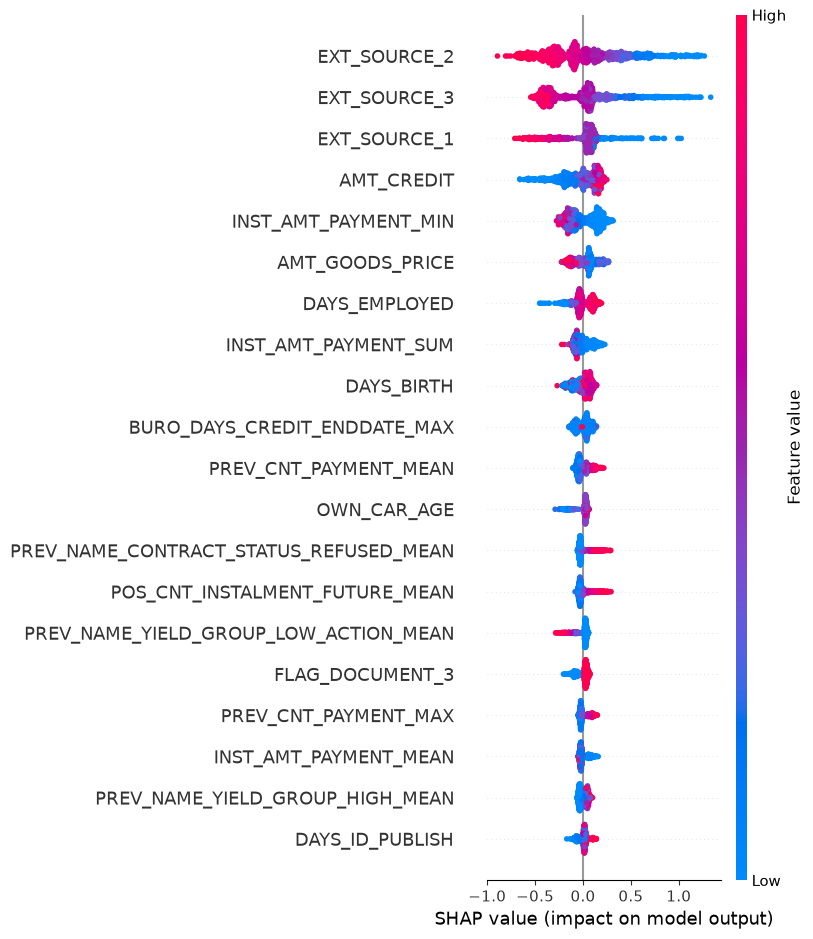

In [20]:
import shap

explainer = shap.TreeExplainer(estimator)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap)

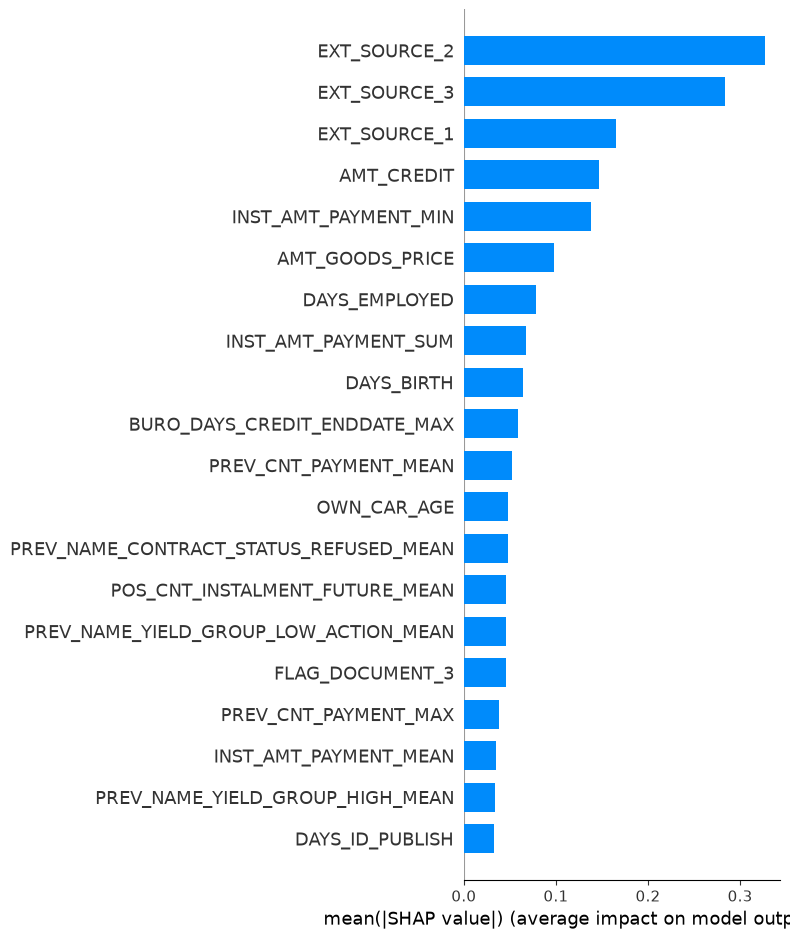

In [21]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar"
)

## 4. Feature importance globale LightGBM

Cette analyse donne une première vision des variables les plus utilisées par le modèle.


In [22]:
feature_importances = pd.DataFrame({
    'feature': X_test_imputed.columns,
    'importance': estimator.feature_importances_
}).sort_values('importance', ascending=False)

feature_importances.head(20)

,feature,importance
2,EXT_SOURCE_1,565
1,EXT_SOURCE_2,418
211,AMT_CREDIT,416
0,EXT_SOURCE_3,363
25,DAYS_BIRTH,267
255,INST_AMT_PAYMENT_MIN,256
29,DAYS_EMPLOYED,200
272,INST_AMT_PAYMENT_SUM,187
164,BURO_DAYS_CREDIT_ENDDATE_MAX,181
141,AMT_GOODS_PRICE,172


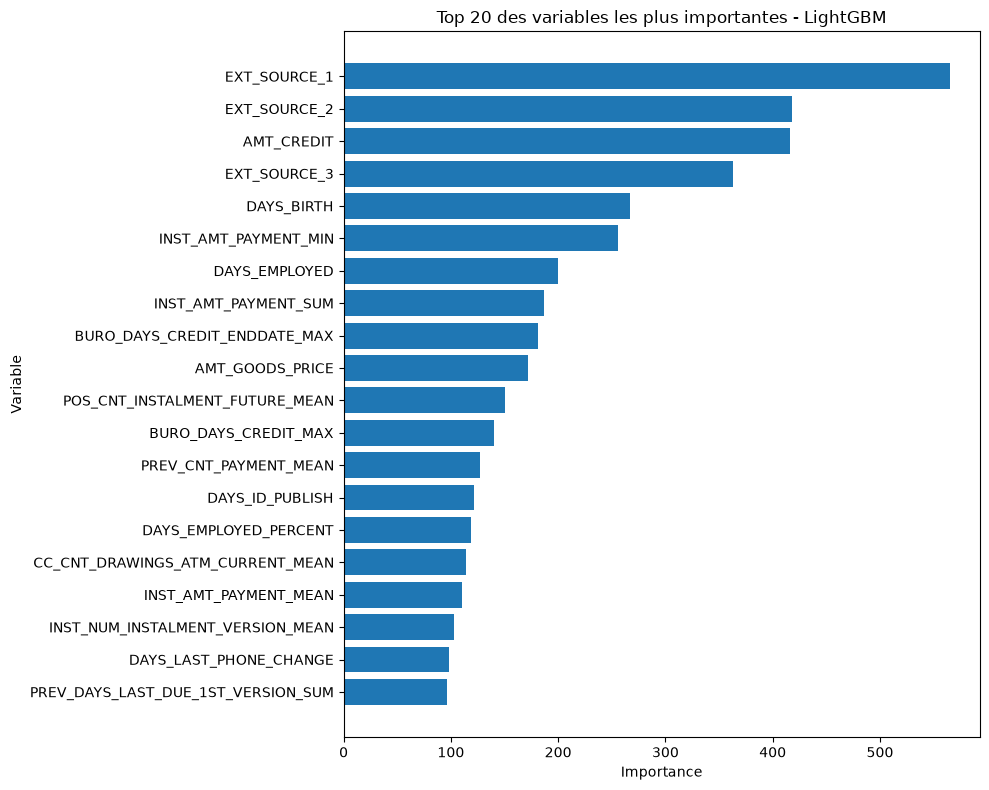

In [23]:
plt.figure(figsize=(10, 8))
top_features = feature_importances.head(20).iloc[::-1]
plt.barh(top_features['feature'], top_features['importance'])
plt.title('Top 20 des variables les plus importantes - LightGBM')
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

## 5. SHAP global

SHAP permet de mesurer l'effet des variables sur les prédictions du modèle. Le graphique global montre quelles variables influencent le plus la probabilité de défaut.


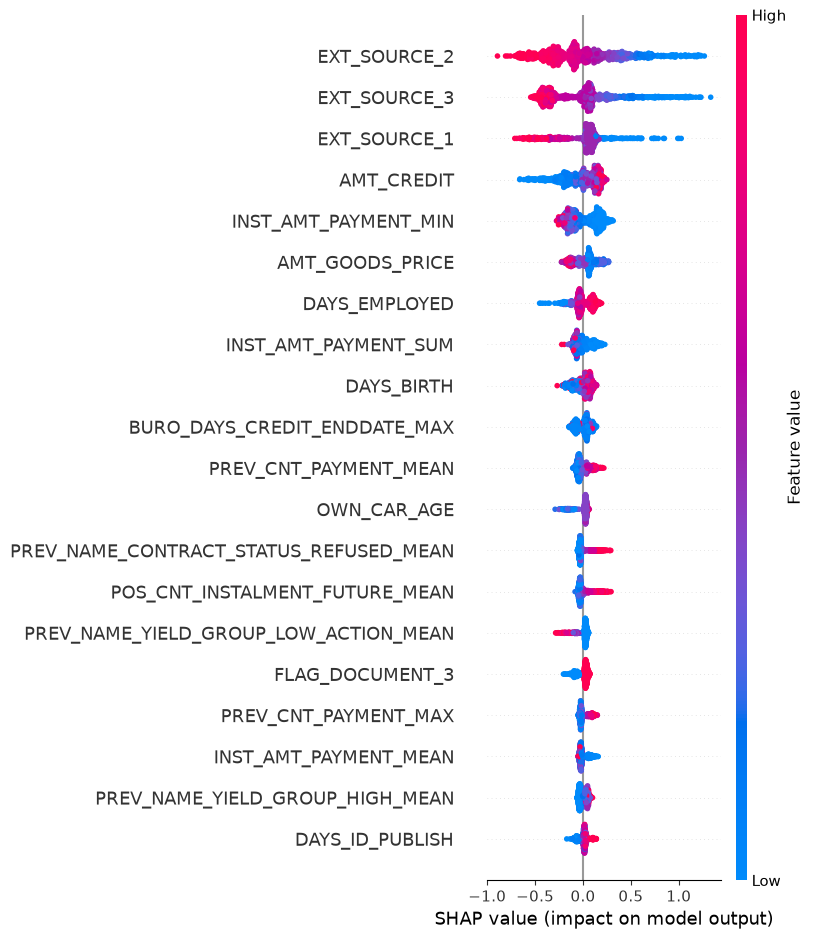

In [24]:
X_sample = X_test_imputed.sample(n=min(1000, len(X_test_imputed)), random_state=42)

explainer = shap.TreeExplainer(estimator)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

shap.summary_plot(shap_values_to_plot, X_sample, show=True)

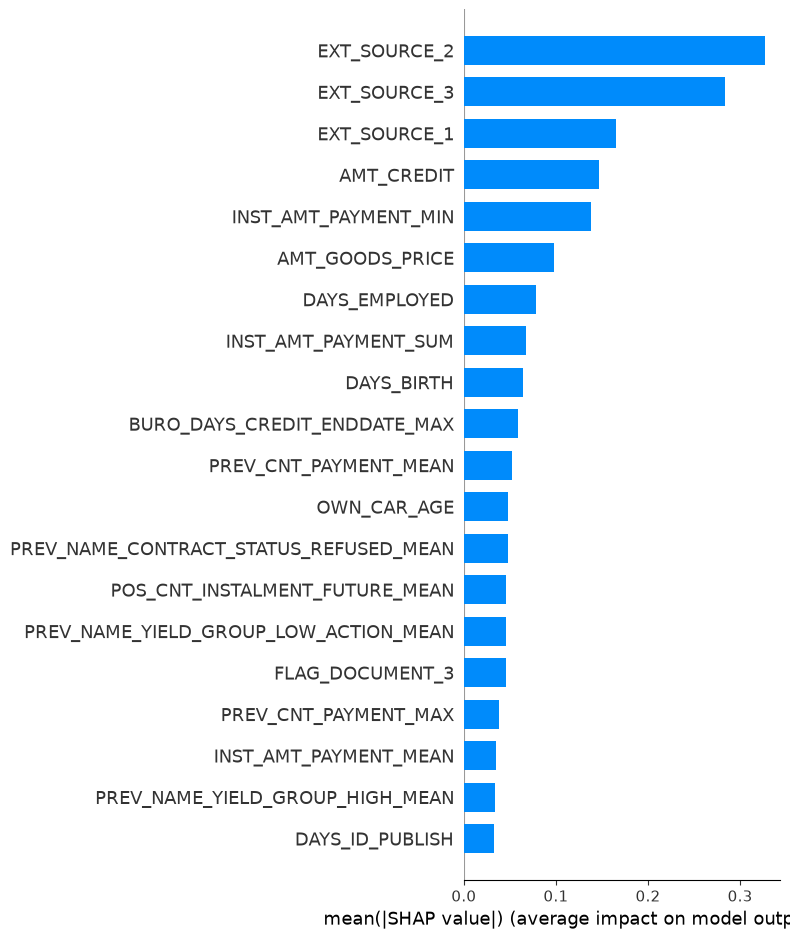

In [25]:
shap.summary_plot(shap_values_to_plot, X_sample, plot_type='bar', show=True)

## 6. SHAP local : explication d'un client

L'analyse locale explique pourquoi un client précis obtient une probabilité de défaut donnée.


In [27]:
client_index = 0

# Client avec les colonnes exactes attendues par le modèle
client_model = X_test_model.iloc[[client_index]]

# Client imputé pour SHAP
client_imputed = X_test_imputed.iloc[[client_index]]

client_proba = model.predict_proba(client_model)[:, 1][0]
client_prediction = int(client_proba >= best_threshold)

print("Index client :", client_index)
print("Probabilité de défaut :", round(client_proba, 4))
print("Seuil métier :", round(best_threshold, 4))
print("Décision :", "Crédit refusé" if client_prediction == 1 else "Crédit accordé")

Index client : 0
Probabilité de défaut : 0.4865
Seuil métier : 0.48
Décision : Crédit refusé


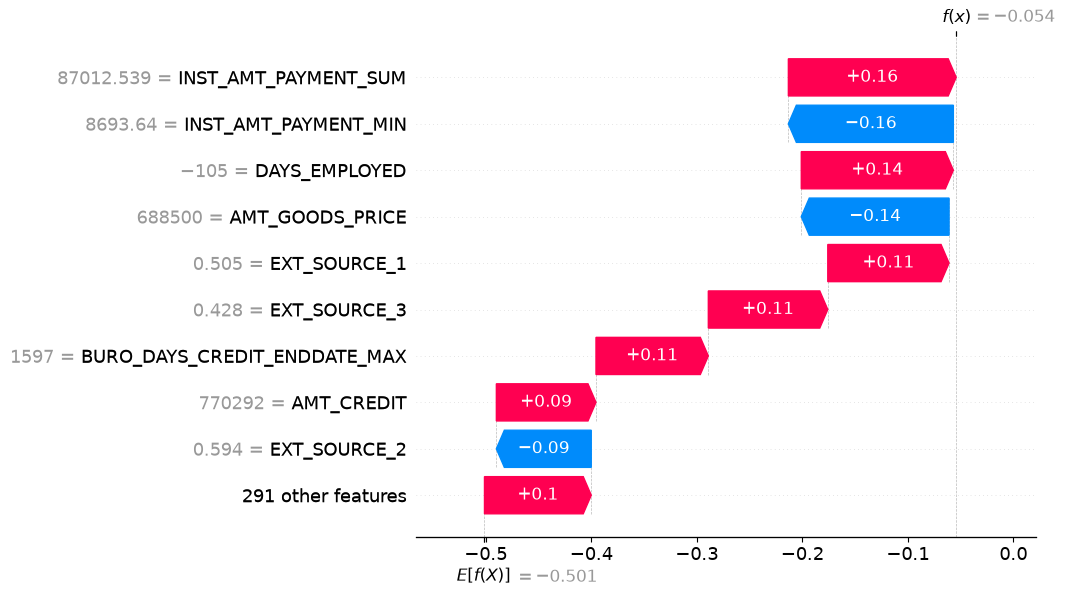

In [28]:
client_shap_values = explainer.shap_values(client_imputed)

shap.waterfall_plot(
    shap.Explanation(
        values=client_shap_values[0],
        base_values=explainer.expected_value,
        data=client_imputed.iloc[0],
        feature_names=client_imputed.columns
    )
)

## Conclusion du notebook 3

L'interprétabilité permet de compléter le modèle de scoring crédit :

- l'analyse globale montre les variables qui influencent le plus le modèle ;
- l'analyse locale permet d'expliquer une décision client par client ;
- SHAP améliore la transparence du score attribué ;
- cette démarche est importante pour un outil utilisé par des chargés d'études dans un contexte financier.

Ce notebook ne remplace pas l'évaluation métier, mais il fournit une base claire pour comprendre les décisions du modèle.
